In [1]:
import pandas as pd
import geopandas as gpd
import shapely
import numpy as np
import json
import os
from functools import partial
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

import nomad.io.base as loader
import nomad.stop_detection.utils as utils
import nomad.stop_detection.postprocessing as pp

import nomad.visit_attribution.visit_attribution as visits
import nomad.filters as filters
import nomad.city_gen as cg

from nomad.map_utils import blocks_to_mercator_gdf
from nomad.contact_estimation import compute_stop_detection_metrics

# Import sequential stop detection
import nomad.stop_detection.sequential as sequential

import warnings

In [2]:
warnings.filterwarnings("ignore", message='Input is timezone-naive; assuming UTC')
warnings.filterwarnings("ignore", category=UserWarning, module='geopandas')  # Ignore geopandas user warnings

In [3]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [4]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

## Preprocess Data for Sequential Stop Detection

Convert position fixes to GeoDataFrame with geometry column.

In [5]:
# Check if sparse_df is already a GeoDataFrame
if not isinstance(sparse_df, gpd.GeoDataFrame):
    # Determine coordinate columns
    if 'longitude' in sparse_df.columns and 'latitude' in sparse_df.columns:
        # Create geometry from longitude/latitude
        from shapely.geometry import Point
        sparse_df['geometry'] = sparse_df.apply(
            lambda row: Point(row['longitude'], row['latitude']), axis=1
        )
        sparse_df = gpd.GeoDataFrame(sparse_df, geometry='geometry', crs='EPSG:4326')
    elif 'x' in sparse_df.columns and 'y' in sparse_df.columns:
        # Create geometry from x/y coordinates
        from shapely.geometry import Point
        sparse_df['geometry'] = sparse_df.apply(
            lambda row: Point(row['x'], row['y']), axis=1
        )
        # Assume projected CRS if using x/y
        sparse_df = gpd.GeoDataFrame(sparse_df, geometry='geometry')
    else:
        raise ValueError("sparse_df must have either (longitude, latitude) or (x, y) columns")

# Verify required columns exist
required_cols = ['user_id', 'timestamp', 'geometry']
missing_cols = [col for col in required_cols if col not in sparse_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Ensure unique index so that .join(labels) inside detect_stops works correctly
sparse_df = sparse_df.reset_index(drop=True)

print(f"Sparse data shape: {sparse_df.shape}")
print(f"Columns: {list(sparse_df.columns)}")
print(f"CRS: {sparse_df.crs}")
print(f"Number of users: {sparse_df['user_id'].nunique()}")

Sparse data shape: (2636, 8)
Columns: ['x', 'y', 'datetime', 'timestamp', 'user_id', 'ha', 'tz_offset', 'geometry']
CRS: None
Number of users: 100


## Configure Algorithm Parameters

In [ ]:
delta_roam_values = np.linspace(1, 125, 100)

config["algos"] = {
    **{f"sequential_delta_{int(dr)}": {
        "func": sequential.detect_stops,
        "params": {
            'dt_max': 60,
            'delta_roam': dr
        }
    } for dr in delta_roam_values}
}

## Run All Algorithms

In [12]:
results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        
        # Map stops to buildings
        stops["location"] = visits.point_in_polygon(
            stops, 
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=10, 
            location_id='location', 
            x='x', 
            y='y'
        )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add delta_roam value to metrics
        metrics['delta_roam'] = algo_config['params']['delta_roam']
        
        results_list.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")

Processing users: 100%|██████████| 100/100 [03:07<00:00,  1.88s/it]

Computed metrics for 10000 user-algorithm combinations


## Aggregate Results

## Visualization: Delta Roam vs Accuracy Metrics

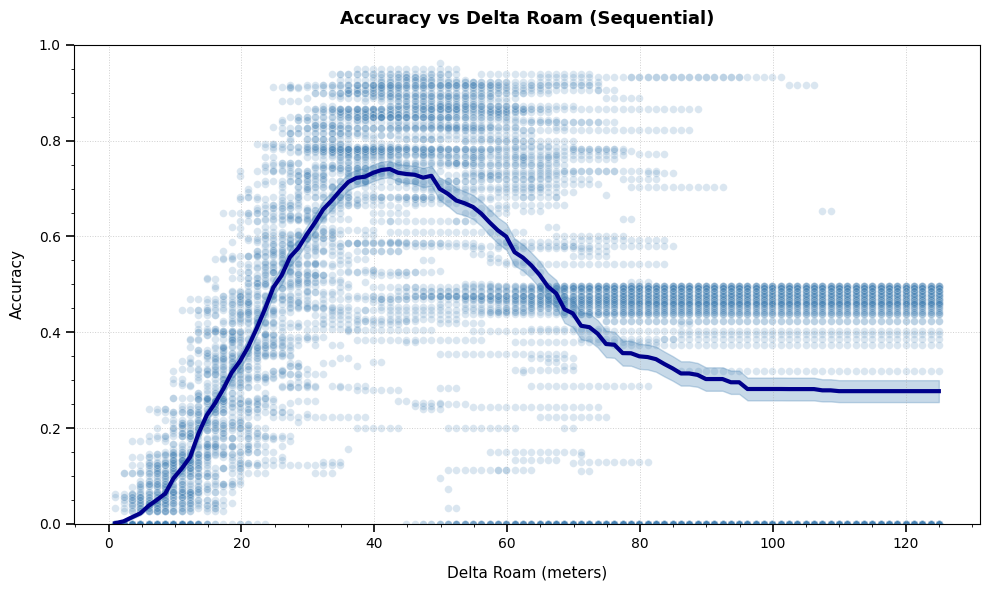

Number of unique delta_roam values: 100


In [11]:
# Create output directory
os.makedirs('figures', exist_ok=True)

def plot_metric_delta_roam(metric, title, save_path='figures'):
    """Plot a metric vs delta_roam for Sequential stop detection."""
    chart_df = results_df.groupby(['delta_roam'])[metric].agg(['mean', 'sem']).reset_index()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='delta_roam', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['delta_roam'], chart_df['mean'], 
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['delta_roam'], 
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Delta Roam (meters)', fontsize=11, labelpad=10)
    ax.set_ylabel(title, fontsize=11, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Delta Roam (Sequential)', fontsize=13, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=10, length=6, width=1.2)
    ax.minorticks_on()
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/sequential_delta_roam_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/sequential_delta_roam_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

# Plot all metrics
plot_metric_delta_roam('recall', 'Accuracy')

print(f"Number of unique delta_roam values: {results_df['delta_roam'].nunique()}")